In [30]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os

In [66]:
from sklearn.model_selection import train_test_split


df = pd.read_csv("datasets/nrel_training_data.csv")
df_feat = df.drop(['County', 'full_timeseries_directory', 'full_timeseries_path'], axis=1)
X = df_feat.drop('isTurbine', axis=1)
y = df_feat['isTurbine']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
def map_coordinates_to_state(latitude, longitude, states_gdf=None, shapefile_path="tl_2025_us_state"):
    """
    Maps latitude and longitude coordinates to their respective US state or territory.
    
    This function uses TIGER/Line Shapefiles from the U.S. Census Bureau to determine
    which state or territory a given coordinate pair falls within.
    
    Args:
        latitude: float or array-like - latitude coordinate(s)
        longitude: float or array-like - longitude coordinate(s)
        states_gdf: geopandas.GeoDataFrame, optional - pre-loaded states GeoDataFrame for efficiency
                    If None, will load from shapefile_path
        shapefile_path: str - path to the shapefile directory or .shp file
                       Default: "tl_2025_us_state"
    
    Returns:
        str or pandas.Series - state/territory name(s), or None/NaN if not found
        
    Example:
        >>> map_coordinates_to_state(40.7128, -74.0060)  # New York City
        'New York'
        >>> map_coordinates_to_state([40.7128, 34.0522], [-74.0060, -118.2437])
        # Returns: ['New York', 'California']
    """
    # Load states GeoDataFrame if not provided
    if states_gdf is None:
        import os
        # Check if path is a directory or file
        if os.path.isdir(shapefile_path):
            # First try the expected filename
            expected_shp = os.path.join(shapefile_path, "tl_2025_us_state.shp")
            if os.path.exists(expected_shp):
                shapefile_path = expected_shp
            else:
                # Look for any .shp file in the directory
                shp_files = [f for f in os.listdir(shapefile_path) if f.endswith('.shp')]
                if shp_files:
                    shapefile_path = os.path.join(shapefile_path, shp_files[0])
                    print(f"Using shapefile: {shp_files[0]}")
                else:
                    raise FileNotFoundError(f"No .shp file found in directory: {shapefile_path}")
        elif not shapefile_path.endswith('.shp'):
            # Check if adding .shp makes it exist
            potential_path = shapefile_path + ".shp"
            if os.path.exists(potential_path):
                shapefile_path = potential_path
            elif os.path.isdir(shapefile_path):
                # It's actually a directory, handle it
                shp_files = [f for f in os.listdir(shapefile_path) if f.endswith('.shp')]
                if shp_files:
                    shapefile_path = os.path.join(shapefile_path, shp_files[0])
                else:
                    raise FileNotFoundError(f"No .shp file found in directory: {shapefile_path}")
        
        states_gdf = gpd.read_file(shapefile_path)
    
    # Handle single coordinate pair
    if isinstance(latitude, (int, float)) and isinstance(longitude, (int, float)):
        point = Point(longitude, latitude)  # Note: Point takes (lon, lat)
        matches = states_gdf[states_gdf.geometry.contains(point)]
        if len(matches) > 0:
            return matches.iloc[0]["NAME"]
        return None
    
    # Handle array-like inputs (batch processing)
    else:
        results = []
        for lat, lon in zip(latitude, longitude):
            point = Point(lon, lat)  # Note: Point takes (lon, lat)
            matches = states_gdf[states_gdf.geometry.contains(point)]
            if len(matches) > 0:
                results.append(matches.iloc[0]["NAME"])
            else:
                results.append(None)
        return pd.Series(results)


def load_states_shapefile(shapefile_path="tl_2025_us_state"):
    """
    Load the states shapefile into a GeoDataFrame for efficient reuse.
    
    Args:
        shapefile_path: str - path to the shapefile directory or .shp file
    
    Returns:
        geopandas.GeoDataFrame - loaded states GeoDataFrame
    """
    import os
    # Check if path is a directory or file
    if os.path.isdir(shapefile_path):
        # First try the expected filename
        expected_shp = os.path.join(shapefile_path, "tl_2025_us_state.shp")
        if os.path.exists(expected_shp):
            shapefile_path = expected_shp
        else:
            # Look for any .shp file in the directory
            shp_files = [f for f in os.listdir(shapefile_path) if f.endswith('.shp')]
            if shp_files:
                shapefile_path = os.path.join(shapefile_path, shp_files[0])
                print(f"Using shapefile: {shp_files[0]}")
            else:
                raise FileNotFoundError(f"No .shp file found in directory: {shapefile_path}")
    elif not shapefile_path.endswith('.shp'):
        # Check if adding .shp makes it exist
        potential_path = shapefile_path + ".shp"
        if os.path.exists(potential_path):
            shapefile_path = potential_path
        elif os.path.isdir(shapefile_path):
            # It's actually a directory, handle it
            shp_files = [f for f in os.listdir(shapefile_path) if f.endswith('.shp')]
            if shp_files:
                shapefile_path = os.path.join(shapefile_path, shp_files[0])
            else:
                raise FileNotFoundError(f"No .shp file found in directory: {shapefile_path}")
    
    return gpd.read_file(shapefile_path)


# Test the function
print("Function loaded successfully!")
print("Usage example:")
print("  state = map_coordinates_to_state(40.7128, -74.0060)  # New York City")
print("  state = map_coordinates_to_state(34.0522, -118.2437)  # Los Angeles")

Function loaded successfully!
Usage example:
  state = map_coordinates_to_state(40.7128, -74.0060)  # New York City
  state = map_coordinates_to_state(34.0522, -118.2437)  # Los Angeles


In [59]:
# Test 1: Test with known US city coordinates
print("=" * 60)
print("TEST 1: Known US City Coordinates")
print("=" * 60)

# Test coordinates for major US cities
test_cities = [
    ("New York City", 40.7128, -74.0060),
    ("Los Angeles", 34.0522, -118.2437),
    ("Chicago", 41.8781, -87.6298),
    ("Houston", 29.7604, -95.3698),
    ("Phoenix", 33.4484, -112.0740),
    ("Austin", 30.2672, -97.7431),
    ("Seattle", 47.6062, -122.3321),
    ("Miami", 25.7617, -80.1918),
]

print("\nTesting single coordinate mapping:")
for city_name, lat, lon in test_cities:
    state = map_coordinates_to_state(lat, lon)
    print(f"  {city_name:20s} ({lat:8.4f}, {lon:9.4f}) -> {state}")

print("\nTesting batch coordinate mapping:")
lats = [lat for _, lat, _ in test_cities]
lons = [lon for _, _, lon in test_cities]
states_batch = map_coordinates_to_state(lats, lons)
print(f"  Batch result type: {type(states_batch)}")
print(f"  First 3 results: {list(states_batch[:3])}")

TEST 1: Known US City Coordinates

Testing single coordinate mapping:
  New York City        ( 40.7128,  -74.0060) -> New York
  Los Angeles          ( 34.0522, -118.2437) -> California
  Chicago              ( 41.8781,  -87.6298) -> Illinois
  Houston              ( 29.7604,  -95.3698) -> Texas
  Phoenix              ( 33.4484, -112.0740) -> Arizona
  Austin               ( 30.2672,  -97.7431) -> Texas
  Seattle              ( 47.6062, -122.3321) -> Washington
  Miami                ( 25.7617,  -80.1918) -> Florida

Testing batch coordinate mapping:
  Batch result type: <class 'pandas.core.series.Series'>
  First 3 results: ['New York', 'California', 'Illinois']


In [60]:
# Test 2: Test with edge cases and territories
print("=" * 60)
print("TEST 2: Edge Cases and Territories")
print("=" * 60)

# Test coordinates that might be in territories or edge cases
edge_cases = [
    ("Washington DC", 38.9072, -77.0369),
    ("Puerto Rico (San Juan)", 18.4655, -66.1057),
    ("Alaska (Anchorage)", 61.2181, -149.9003),
    ("Hawaii (Honolulu)", 21.3099, -157.8581),
    ("Offshore (should be None)", 28.0, -80.0),  # Off Florida coast
]

print("\nTesting edge cases:")
for location, lat, lon in edge_cases:
    state = map_coordinates_to_state(lat, lon)
    print(f"  {location:30s} ({lat:8.4f}, {lon:9.4f}) -> {state}")

TEST 2: Edge Cases and Territories

Testing edge cases:
  Washington DC                  ( 38.9072,  -77.0369) -> District of Columbia
  Puerto Rico (San Juan)         ( 18.4655,  -66.1057) -> Puerto Rico
  Alaska (Anchorage)             ( 61.2181, -149.9003) -> Alaska
  Hawaii (Honolulu)              ( 21.3099, -157.8581) -> Hawaii
  Offshore (should be None)      ( 28.0000,  -80.0000) -> None


In [61]:
# Test 3: Test with a small sample from the actual dataset
print("=" * 60)
print("TEST 3: Sample from Actual Dataset")
print("=" * 60)

# Load a small sample of data with unknown states
if 'df' in locals() or 'df' in globals():
    # Get a sample of rows with unknown states
    df_sample = df[df['State'] == 'Unknown'].head(10).copy()
    
    if len(df_sample) > 0:
        print(f"\nTesting with {len(df_sample)} rows from dataset with 'Unknown' states:")
        print("\nBefore mapping:")
        print(df_sample[['latitude', 'longitude', 'State']].head())
        
        # Test the mapping function
        print("\nMapping coordinates to states...")
        states_result = map_coordinates_to_state(
            df_sample['latitude'].values,
            df_sample['longitude'].values
        )
        
        print("\nResults:")
        for idx, (lat, lon, state) in enumerate(zip(
            df_sample['latitude'].values,
            df_sample['longitude'].values,
            states_result
        )):
            print(f"  Row {idx+1}: ({lat:8.4f}, {lon:9.4f}) -> {state}")
        
        print(f"\nSuccessfully mapped {states_result.notna().sum()} out of {len(df_sample)} coordinates")
    else:
        print("No rows with 'Unknown' states found in current df variable.")
else:
    print("DataFrame 'df' not found. Run the data loading cells first.")

TEST 3: Sample from Actual Dataset
No rows with 'Unknown' states found in current df variable.


In [62]:
# Test 4: Performance test - load shapefile once and reuse
print("=" * 60)
print("TEST 4: Performance Test (Reusing Loaded Shapefile)")
print("=" * 60)

import time

# Load shapefile once
print("\nLoading shapefile...")
start_time = time.time()
states_gdf = load_states_shapefile()
load_time = time.time() - start_time
print(f"Shapefile loaded in {load_time:.3f} seconds")
print(f"Number of states/territories: {len(states_gdf)}")
print(f"State names: {sorted(states_gdf['NAME'].tolist())[:10]}...")  # Show first 10

# Test with pre-loaded shapefile
test_coords = [(40.7128, -74.0060), (34.0522, -118.2437), (41.8781, -87.6298)]
lats = [lat for lat, _ in test_coords]
lons = [lon for _, lon in test_coords]

print("\nTesting with pre-loaded shapefile (should be faster):")
start_time = time.time()
states_result = map_coordinates_to_state(lats, lons, states_gdf=states_gdf)
elapsed = time.time() - start_time
print(f"  Mapped {len(test_coords)} coordinates in {elapsed:.4f} seconds")
print(f"  Results: {list(states_result)}")

TEST 4: Performance Test (Reusing Loaded Shapefile)

Loading shapefile...
Shapefile loaded in 0.104 seconds
Number of states/territories: 56
State names: ['Alabama', 'Alaska', 'American Samoa', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Commonwealth of the Northern Mariana Islands', 'Connecticut', 'Delaware']...

Testing with pre-loaded shapefile (should be faster):
  Mapped 3 coordinates in 0.0095 seconds
  Results: ['New York', 'California', 'Illinois']


In [63]:
# Test 5: Verify the shapefile contains expected states
print("=" * 60)
print("TEST 5: Verify Shapefile Contents")
print("=" * 60)

states_gdf = load_states_shapefile()
print(f"\nTotal states/territories in shapefile: {len(states_gdf)}")
print(f"\nAll states/territories:")
print(states_gdf[['NAME']].sort_values('NAME').to_string(index=False))

# Check if it has the expected 50 states + DC + territories
expected_count = 50  # 50 states
print(f"\nShapefile contains {len(states_gdf)} entities")
print("This should include 50 states plus DC and territories (Puerto Rico, etc.)")

TEST 5: Verify Shapefile Contents

Total states/territories in shapefile: 56

All states/territories:
                                        NAME
                                     Alabama
                                      Alaska
                              American Samoa
                                     Arizona
                                    Arkansas
                                  California
                                    Colorado
Commonwealth of the Northern Mariana Islands
                                 Connecticut
                                    Delaware
                        District of Columbia
                                     Florida
                                     Georgia
                                        Guam
                                      Hawaii
                                       Idaho
                                    Illinois
                                     Indiana
                                        Iow

In [64]:
def fill_missing_states_from_coordinates(df, lat_col='latitude', lon_col='longitude', 
                                         state_col='State', shapefile_path="tl_2025_us_state"):
    """
    Fill missing or 'Unknown' state values in a DataFrame using latitude/longitude coordinates.
    
    This function is optimized for batch processing and will only process rows where
    the state is missing or 'Unknown'.
    
    Args:
        df: pandas.DataFrame - DataFrame with latitude and longitude columns
        lat_col: str - name of the latitude column (default: 'latitude')
        lon_col: str - name of the longitude column (default: 'longitude')
        state_col: str - name of the state column to fill (default: 'State')
        shapefile_path: str - path to the shapefile directory or .shp file
    
    Returns:
        pandas.DataFrame - DataFrame with updated state values
    
    Example:
        >>> df = fill_missing_states_from_coordinates(df)
    """
    # Load states shapefile once
    states_gdf = load_states_shapefile(shapefile_path)
    
    # Create a copy to avoid modifying the original
    df = df.copy()
    
    # Identify rows that need state mapping
    if state_col not in df.columns:
        df[state_col] = None
    
    mask = df[state_col].isna() | (df[state_col] == 'Unknown')
    rows_to_process = df[mask].copy()
    
    if len(rows_to_process) == 0:
        print("No rows need state mapping.")
        return df
    
    print(f"Processing {len(rows_to_process)} rows with missing/unknown states...")
    
    # Process in batches for efficiency
    batch_size = 1000
    results = []
    
    for i in range(0, len(rows_to_process), batch_size):
        batch = rows_to_process.iloc[i:i+batch_size]
        batch_states = map_coordinates_to_state(
            batch[lat_col].values,
            batch[lon_col].values,
            states_gdf=states_gdf
        )
        results.extend(batch_states)
        
        if (i + batch_size) % 5000 == 0:
            print(f"  Processed {min(i + batch_size, len(rows_to_process))} rows...")
    
    # Update the DataFrame
    df.loc[mask, state_col] = results
    
    # Count how many were successfully mapped
    newly_mapped = mask & df[state_col].notna() & (df[state_col] != 'Unknown')
    print(f"Successfully mapped {newly_mapped.sum()} coordinates to states.")
    
    return df

In [67]:
unknown_percentage = X_train['State'].value_counts()['Unknown']/X_train.shape[0]
unknown_percentage

np.float64(0.0747144503824793)

In [68]:
df_unknown = X_train[X_train["State"].isna() | (X_train["State"] == "Unknown")]
df_unknown[["latitude", "longitude"]].describe()


,latitude,longitude
count,11408.000000,11408.000000
mean,34.110334,-82.369502
std,6.025413,10.414690
min,20.266960,-125.309982
25%,28.966887,-86.067605
50%,34.141788,-80.648697
75%,38.908555,-75.290680
max,49.009869,-63.801971


In [69]:
X_train = X_train[['fraction_of_usable_area', 'capacity', 'wind_speed', 'capacity_factor', 'latitude', 'longitude', 'State']]

In [70]:
X_train = fill_missing_states_from_coordinates(X_train)

Processing 11408 rows with missing/unknown states...
  Processed 5000 rows...
  Processed 10000 rows...
Successfully mapped 1549 coordinates to states.


In [71]:
X_train['State'].isna().sum()

np.int64(9859)

In [76]:
def add_region_column(df, state_col='State', region_col='Region', inplace=False):
    """
    Adds a Region column to a DataFrame by mapping states to regions.
    
    Maps US states to regions: Great Plains, West Coast, Northeast, Southeast, 
    Midwest, Mountain West, and handles offshore/unknown values.
    
    Args:
        df: pandas.DataFrame - DataFrame with a State column
        state_col: str - name of the state column (default: 'State')
        region_col: str - name of the region column to create (default: 'Region')
        inplace: bool - if True, modify df in place; if False, return a copy (default: False)
        
    Returns:
        pandas.DataFrame - DataFrame with Region column added (if inplace=False)
        
    Example:
        >>> df = add_region_column(df)
        >>> df = add_region_column(df, state_col='State', region_col='Region')
    """
    def map_state_to_region(state):
        """Helper function to map a single state to a region"""
        # Handle None, NaN, or 'Unknown' values
        if pd.isna(state) or state == 'Unknown' or state is None:
            return 'Offshore/International'
        
        state = str(state).strip()
        
        # Northeast Region
        northeast = ['Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 
                     'Rhode Island', 'Connecticut', 'New York', 'New Jersey', 
                     'Pennsylvania']
        
        # West Coast
        west_coast = ['California', 'Oregon', 'Washington']
        
        # Great Plains
        great_plains = ['North Dakota', 'South Dakota', 'Nebraska', 'Kansas', 
                        'Oklahoma', 'Texas', 'Montana', 'Wyoming', 'Colorado']
        
        # Southeast
        southeast = ['Delaware', 'Maryland', 'District of Columbia', 'Virginia', 
                     'West Virginia', 'Kentucky', 'Tennessee', 'North Carolina', 
                     'South Carolina', 'Georgia', 'Florida', 'Alabama', 
                     'Mississippi', 'Arkansas', 'Louisiana']
        
        # Midwest (excluding Great Plains states)
        midwest = ['Ohio', 'Michigan', 'Indiana', 'Illinois', 'Wisconsin', 
                   'Minnesota', 'Iowa', 'Missouri']
        
        # Mountain West (excluding Great Plains states)
        mountain_west = ['Idaho', 'Utah', 'Nevada', 'New Mexico', 'Arizona']
        
        # Other
        other = ['Alaska', 'Hawaii']
        
        # Territories
        territories = ['Puerto Rico', 'US Virgin Islands', 'Guam', 
                       'American Samoa', 'Commonwealth of the Northern Mariana Islands']
        
        # Map to regions
        if state in northeast:
            return 'Northeast'
        elif state in west_coast:
            return 'West Coast'
        elif state in great_plains:
            return 'Great Plains'
        elif state in southeast:
            return 'Southeast'
        elif state in midwest:
            return 'Midwest'
        elif state in mountain_west:
            return 'Mountain West'
        elif state in other:
            return 'Other'
        elif state in territories:
            return 'Territories'
        else:
            # Fallback for any unmapped states
            return 'Offshore/International'
    
    # Create a copy if not inplace
    if not inplace:
        df = df.copy()
    
    # Apply the mapping to create Region column
    df[region_col] = df[state_col].apply(map_state_to_region)
    
    return df

In [80]:
def categorize_wind_speed(df, wind_speed_col='wind_speed', category_col='wind_speed_category', 
                         method='fixed', inplace=False):
    """
    Categorizes wind speeds into "Low", "Medium", "High", "Very High" categories.
    
    Args:
        df: pandas.DataFrame - DataFrame with a wind_speed column
        wind_speed_col: str - name of the wind speed column (default: 'wind_speed')
        category_col: str - name of the category column to create (default: 'wind_speed_category')
        method: str - 'fixed' for fixed thresholds or 'quantile' for quantile-based (default: 'fixed')
        inplace: bool - if True, modify df in place; if False, return a copy (default: False)
        
    Returns:
        pandas.DataFrame - DataFrame with wind_speed_category column added (if inplace=False)
        
    Fixed Thresholds (m/s):
        - Low: < 6.0 m/s (marginal for wind energy)
        - Medium: 6.0 - 8.0 m/s (acceptable for wind energy)
        - High: 8.0 - 10.0 m/s (good for wind energy)
        - Very High: >= 10.0 m/s (excellent for wind energy)
        
    Example:
        >>> df = categorize_wind_speed(df)
        >>> df = categorize_wind_speed(df, method='quantile')
    """
    # Create a copy if not inplace
    if not inplace:
        df = df.copy()
    
    if method == 'fixed':
        # Fixed thresholds based on wind energy industry standards (m/s)
        def map_wind_speed(speed):
            if pd.isna(speed):
                return 'Unknown'
            elif speed < 6.0:
                return 'Low'
            elif speed < 8.0:
                return 'Medium'
            elif speed < 10.0:
                return 'High'
            else:
                return 'Very High'
        
        df[category_col] = df[wind_speed_col].apply(map_wind_speed)
        
    elif method == 'quantile':
        # Use quantiles to create equal-sized categories
        q25 = df[wind_speed_col].quantile(0.25)
        q50 = df[wind_speed_col].quantile(0.50)
        q75 = df[wind_speed_col].quantile(0.75)
        
        def map_wind_speed_quantile(speed):
            if pd.isna(speed):
                return 'Unknown'
            elif speed < q25:
                return 'Low'
            elif speed < q50:
                return 'Medium'
            elif speed < q75:
                return 'High'
            else:
                return 'Very High'
        
        df[category_col] = df[wind_speed_col].apply(map_wind_speed_quantile)
        print(f"Quantile thresholds: Low<{q25:.2f}, Medium<{q50:.2f}, High<{q75:.2f}, Very High>={q75:.2f} m/s")
    
    else:
        raise ValueError("method must be 'fixed' or 'quantile'")
    
    return df

# First, let's check the wind speed distribution to understand the data
print("Wind Speed Statistics:")
print(X_train['wind_speed'].describe())
print(f"\nWind Speed Range: {X_train['wind_speed'].min():.2f} - {X_train['wind_speed'].max():.2f} m/s")
print(f"\nQuantiles:")
print(f"  25th percentile: {X_train['wind_speed'].quantile(0.25):.2f} m/s")
print(f"  50th percentile (median): {X_train['wind_speed'].quantile(0.50):.2f} m/s")
print(f"  75th percentile: {X_train['wind_speed'].quantile(0.75):.2f} m/s")

Wind Speed Statistics:
count    152688.000000
mean          7.758581
std           0.975115
min           2.290000
25%           7.250000
50%           7.810000
75%           8.340000
max          12.800000
Name: wind_speed, dtype: float64

Wind Speed Range: 2.29 - 12.80 m/s

Quantiles:
  25th percentile: 7.25 m/s
  50th percentile (median): 7.81 m/s
  75th percentile: 8.34 m/s


In [81]:
# Apply the categorization using fixed thresholds (industry standard)
X_train = categorize_wind_speed(X_train, method='fixed')

# Check the distribution
print("\nWind Speed Category Distribution:")
print(X_train['wind_speed_category'].value_counts())
print(f"\nCategory percentages:")
print(X_train['wind_speed_category'].value_counts(normalize=True) * 100)

# Show some examples
print("\nSample of categorized data:")
print(X_train[['wind_speed', 'wind_speed_category']].head(20))


Wind Speed Category Distribution:
wind_speed_category
Medium       82393
High         60157
Low           7172
Very High     2966
Name: count, dtype: int64

Category percentages:
wind_speed_category
Medium       53.961673
High         39.398643
Low           4.697160
Very High     1.942523
Name: proportion, dtype: float64

Sample of categorized data:
        wind_speed wind_speed_category
49829         7.48              Medium
49296         8.31                High
40881         8.92                High
61325        10.61           Very High
14647         8.38                High
155899        9.40                High
24678         8.00                High
48255         8.23                High
56027         7.07              Medium
177552        7.75              Medium
73173         4.90                 Low
40686         9.01                High
87823         7.31              Medium
77071         6.40              Medium
124929        7.05              Medium
59459         7.76    

In [101]:
def categorize_capacity(df, capacity_col='capacity', category_col='capacity_category', 
                        method='fixed', inplace=False):
    """
    Categorizes capacity into "Low", "Medium", "High", "Very High" categories.
    
    Args:
        df: pandas.DataFrame - DataFrame with a capacity column
        capacity_col: str - name of the capacity column (default: 'capacity')
        category_col: str - name of the category column to create (default: 'capacity_category')
        method: str - 'fixed' for fixed thresholds or 'quantile' for quantile-based (default: 'fixed')
        inplace: bool - if True, modify df in place; if False, return a copy (default: False)
        
    Returns:
        pandas.DataFrame - DataFrame with capacity_category column added (if inplace=False)
        
    Fixed Thresholds (inclusive ranges):
        - Category 1: 2-4
        - Category 2: 6-8
        - Category 3: 10-12
        - Category 4: 14-16
        - Values outside these ranges are categorized as "Very Low (<2)", "Gap" ranges, or "Very High (>16)"
        
    Example:
        >>> df = categorize_capacity(df)
        >>> df = categorize_capacity(df, method='quantile')
    """
    # Create a copy if not inplace
    if not inplace:
        df = df.copy()
    
    if method == 'fixed':
        # Fixed thresholds with specific ranges (inclusive)
        # Category 1: 2-4, Category 2: 6-8, Category 3: 10-12, Category 4: 14-16
        def map_capacity(cap):
            if pd.isna(cap):
                return 'Unknown'
            elif 2 <= cap <= 4:
                return '2-4'
            elif 6 <= cap <= 8:
                return '6-8'
            elif 10 <= cap <= 12:
                return '10-12'
            elif 14 <= cap <= 16:
                return '14-16'
            elif cap < 2:
                return 'Very Low (<2)'
            elif 4 < cap < 6:
                return 'Gap (4-6)'
            elif 8 < cap < 10:
                return 'Gap (8-10)'
            elif 12 < cap < 14:
                return 'Gap (12-14)'
            else:  # cap > 16
                return 'Very High (>16)'
        
        df[category_col] = df[capacity_col].apply(map_capacity)
        
    elif method == 'quantile':
        # Use quantiles to create equal-sized categories
        q25 = df[capacity_col].quantile(0.25)
        q50 = df[capacity_col].quantile(0.50)
        q75 = df[capacity_col].quantile(0.75)
        
        def map_capacity_quantile(cap):
            if pd.isna(cap):
                return 'Unknown'
            elif cap < q25:
                return 'Low'
            elif cap < q50:
                return 'Medium'
            elif cap < q75:
                return 'High'
            else:
                return 'Very High'
        
        df[category_col] = df[capacity_col].apply(map_capacity_quantile)
        print(f"Quantile thresholds: Low<{q25:.2f}, Medium<{q50:.2f}, High<{q75:.2f}, Very High>={q75:.2f}")
    
    else:
        raise ValueError("method must be 'fixed' or 'quantile'")
    
    return df

# First, let's check the capacity distribution to understand the data
print("Capacity Statistics:")
print(X_train['capacity'].describe())
print(f"\nCapacity Range: {X_train['capacity'].min():.2f} - {X_train['capacity'].max():.2f}")
print(f"\nQuantiles:")
print(f"  25th percentile: {X_train['capacity'].quantile(0.25):.2f}")
print(f"  50th percentile (median): {X_train['capacity'].quantile(0.50):.2f}")
print(f"  75th percentile: {X_train['capacity'].quantile(0.75):.2f}")

Capacity Statistics:
count    152688.000000
mean         14.709303
std           2.925766
min           2.000000
25%          16.000000
50%          16.000000
75%          16.000000
max          16.000000
Name: capacity, dtype: float64

Capacity Range: 2.00 - 16.00

Quantiles:
  25th percentile: 16.00
  50th percentile (median): 16.00
  75th percentile: 16.00


In [102]:
# Apply the categorization using fixed thresholds (industry standard)
X_train = categorize_capacity(X_train, method='fixed')

# Check the distribution
print("\nCapacity Category Distribution:")
print(X_train['capacity_category'].value_counts())
print(f"\nCategory percentages:")
print(X_train['capacity_category'].value_counts(normalize=True) * 100)

# Show some examples
print("\nSample of categorized data:")
print(X_train[['capacity', 'capacity_category']].head(20))


Capacity Category Distribution:
capacity_category
14-16    127639
10-12     17654
2-4        4534
6-8        2861
Name: count, dtype: int64

Category percentages:
capacity_category
14-16    83.594651
10-12    11.562140
2-4       2.969454
6-8       1.873756
Name: proportion, dtype: float64

Sample of categorized data:
        capacity capacity_category
49829         16             14-16
49296         16             14-16
40881         16             14-16
61325         16             14-16
14647         14             14-16
155899        16             14-16
24678         16             14-16
48255         16             14-16
56027          6               6-8
177552        16             14-16
73173         16             14-16
40686         16             14-16
87823         16             14-16
77071         16             14-16
124929        16             14-16
59459         12             10-12
22877         16             14-16
81160         16             14-16
123940        1

In [77]:
X_train = add_region_column(X_train)

(array([1.2000e+01, 6.0000e+00, 3.3000e+01, 6.7000e+01, 1.6800e+02,
        2.1900e+02, 4.3300e+02, 8.6700e+02, 1.4700e+03, 2.0720e+03,
        3.3850e+03, 4.8030e+03, 7.4480e+03, 1.3669e+04, 2.4036e+04,
        2.3732e+04, 2.5181e+04, 2.2793e+04, 1.1162e+04, 4.4950e+03,
        2.3100e+03, 1.3610e+03, 8.2600e+02, 1.2350e+03, 7.6700e+02,
        9.7000e+01, 2.6000e+01, 7.0000e+00, 5.0000e+00, 3.0000e+00]),
 array([ 2.29      ,  2.64033333,  2.99066667,  3.341     ,  3.69133333,
         4.04166667,  4.392     ,  4.74233333,  5.09266667,  5.443     ,
         5.79333333,  6.14366667,  6.494     ,  6.84433333,  7.19466667,
         7.545     ,  7.89533333,  8.24566667,  8.596     ,  8.94633333,
         9.29666667,  9.647     ,  9.99733333, 10.34766667, 10.698     ,
        11.04833333, 11.39866667, 11.749     , 12.09933333, 12.44966667,
        12.8       ]),
 <BarContainer object of 30 artists>)

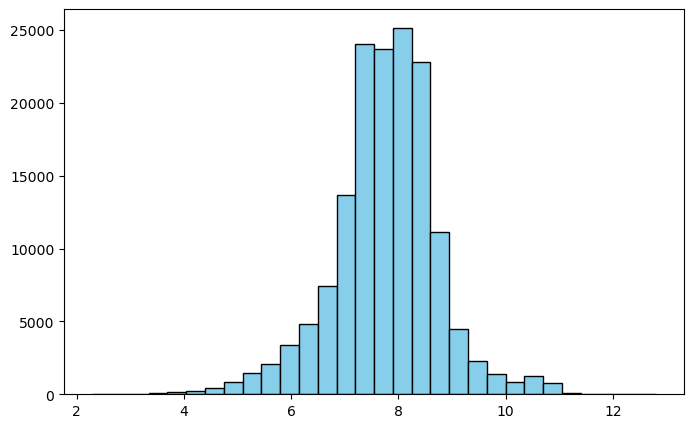

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(X_train['wind_speed'], bins=30, color='skyblue', edgecolor='k')

Interaction features

In [88]:
X_train['combined_wind_rescource'] = X_train['wind_speed'] * X_train['capacity_factor']
X_train['potential_with_constraints'] = X_train['capacity'] * X_train['fraction_of_usable_area']

<Figure size 1800x1200 with 0 Axes>

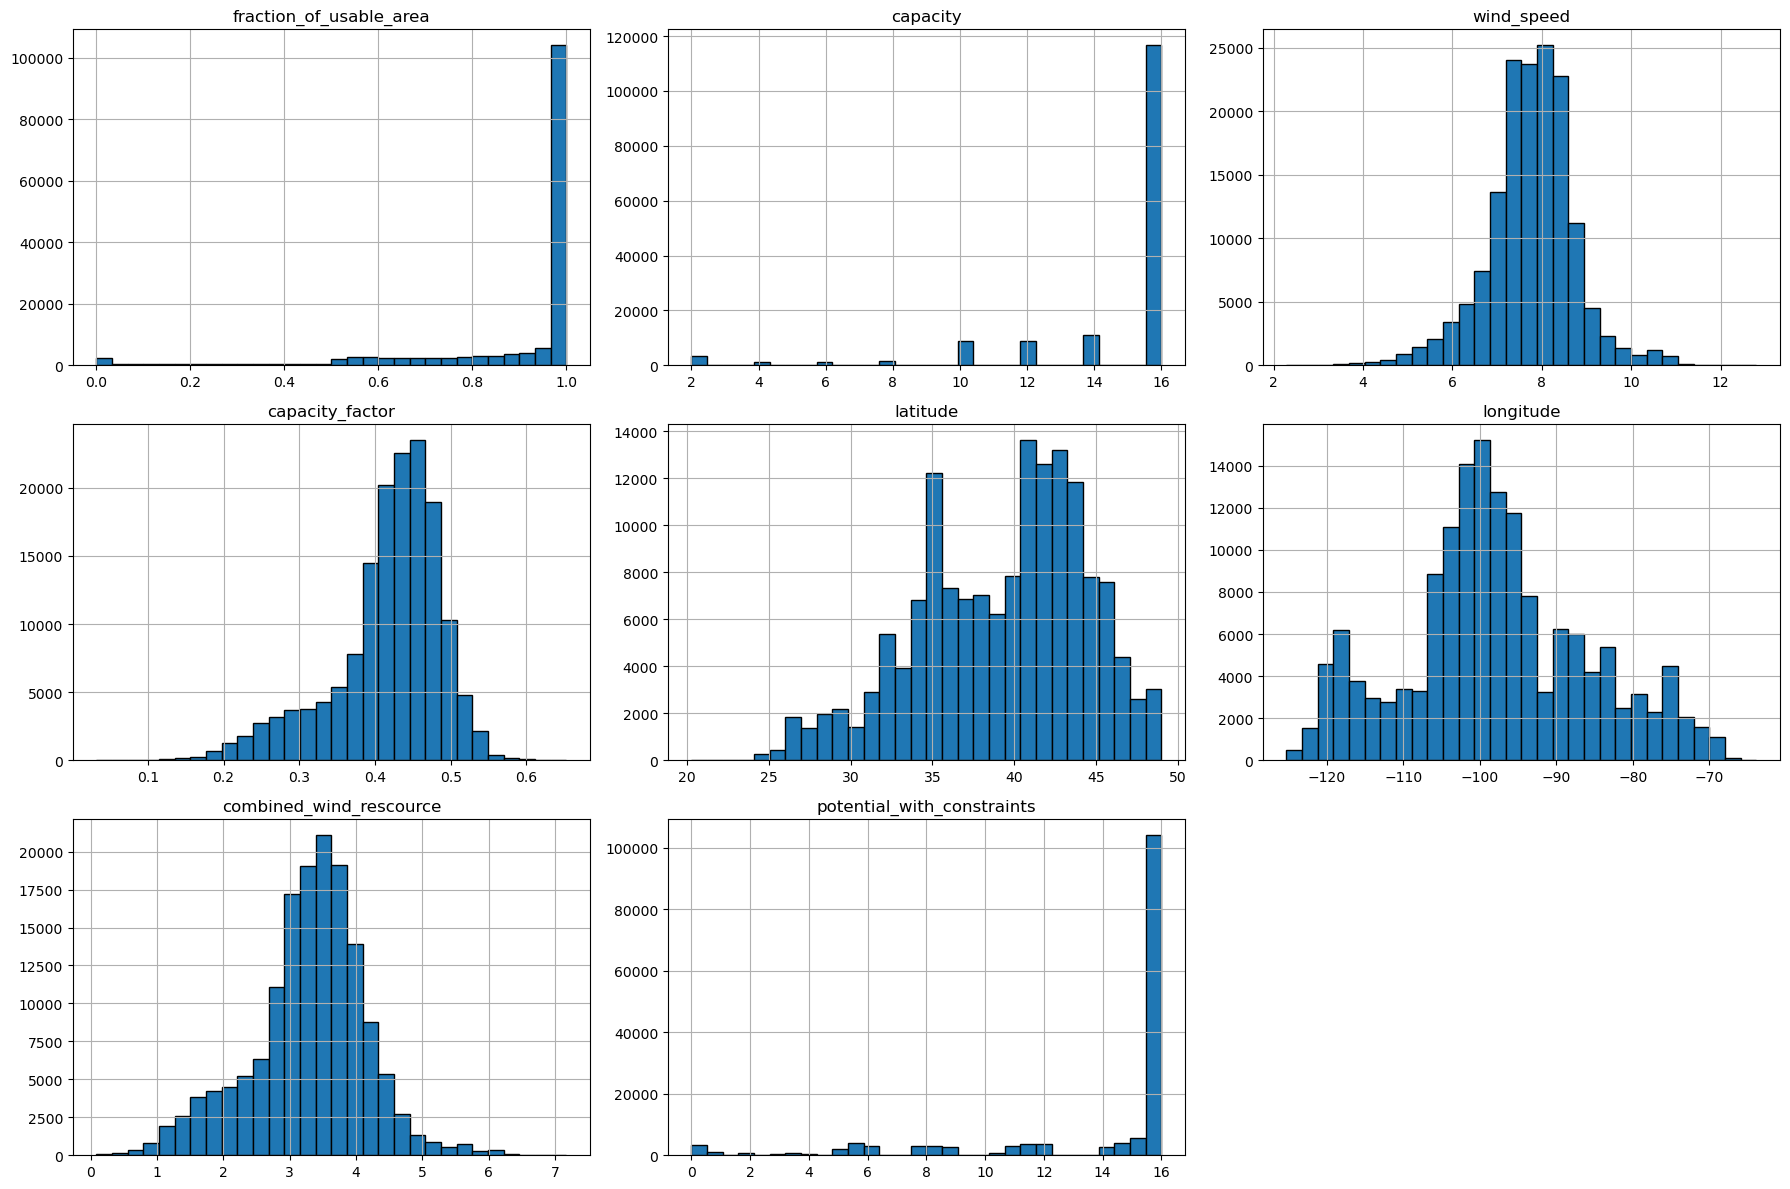

In [103]:
plt.figure(figsize=(18, 12))
X_train.hist(bins=30, figsize=(18, 12), edgecolor='k')
plt.tight_layout()
plt.show()

In [105]:
X_train.columns

Index(['fraction_of_usable_area', 'capacity', 'wind_speed', 'capacity_factor',
       'latitude', 'longitude', 'State', 'Region', 'wind_speed_category',
       'combined_wind_rescource', 'potential_with_constraints',
       'capacity_category'],
      dtype='object')

In [106]:
X_train.drop(columns=['latitude', 'longitude'], inplace=True)

## Select features and test each one

In [107]:
# Create all X_train combinations for testing

# Base features (always included)
base_features = ['fraction_of_usable_area', 'capacity_factor']

# Numeric features
numeric_wind = 'wind_speed'
numeric_capacity = 'capacity'

# Categorical features
cat_wind = 'wind_speed_category'
cat_capacity = 'capacity_category'

# Geographic features
state_feature = 'State'
region_feature = 'Region'

# New engineered features
new_feature_1 = 'combined_wind_rescource'
new_feature_2 = 'potential_with_constraints'

# X_train_1: Base + numeric features + new features (baseline with new features)
X_train_1 = X_train[base_features + [numeric_wind, numeric_capacity, new_feature_1, new_feature_2]]

# X_train_2: Base + numeric features - no new features (baseline without new features)
X_train_2 = X_train[base_features + [numeric_wind, numeric_capacity]]

# X_train_3: Base + categories + new features
X_train_3 = X_train[base_features + [cat_wind, cat_capacity, new_feature_1, new_feature_2]]

# X_train_4: Base + categories - no new features
X_train_4 = X_train[base_features + [cat_wind, cat_capacity]]

# X_train_5: Base + numeric + State + new features
X_train_5 = X_train[base_features + [numeric_wind, numeric_capacity, state_feature, new_feature_1, new_feature_2]]

# X_train_6: Base + numeric + State - no new features
X_train_6 = X_train[base_features + [numeric_wind, numeric_capacity, state_feature]]

# X_train_7: Base + numeric + Region + new features
X_train_7 = X_train[base_features + [numeric_wind, numeric_capacity, region_feature, new_feature_1, new_feature_2]]

# X_train_8: Base + numeric + Region - no new features
X_train_8 = X_train[base_features + [numeric_wind, numeric_capacity, region_feature]]

# X_train_9: Base + categories + State + new features
X_train_9 = X_train[base_features + [cat_wind, cat_capacity, state_feature, new_feature_1, new_feature_2]]

# X_train_10: Base + categories + State - no new features
X_train_10 = X_train[base_features + [cat_wind, cat_capacity, state_feature]]

# X_train_11: Base + categories + Region + new features
X_train_11 = X_train[base_features + [cat_wind, cat_capacity, region_feature, new_feature_1, new_feature_2]]

# X_train_12: Base + categories + Region - no new features
X_train_12 = X_train[base_features + [cat_wind, cat_capacity, region_feature]]

print(f"Created 12 X_train combinations for testing")
print(f"\nX_train_1 shape: {X_train_1.shape}")
print(f"X_train_2 shape: {X_train_2.shape}")
print(f"X_train_3 shape: {X_train_3.shape}")

# Convert categorical features to numeric labels
# wind_speed_category: Low=1, Medium=2, High=3, Very High=4
# capacity_category: Ordered by numeric value (Very Low=1, 2-4=2, 6-8=3, 10-12=4, 14-16=5, etc.)

def encode_categorical_to_numeric(train_set, cat_feature, mapping):
    """Convert a categorical feature to numeric labels"""
    if cat_feature in train_set.columns:
        train_set = train_set.copy()
        train_set[cat_feature] = train_set[cat_feature].map(mapping).fillna(0).astype(int)
    return train_set

# Define mappings for categorical features
wind_speed_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Very High': 4,
    'Unknown': 0
}

capacity_mapping = {
    'Very Low (<2)': 1,
    '2-4': 2,
    'Gap (4-6)': 3,
    '6-8': 4,
    'Gap (8-10)': 5,
    '10-12': 6,
    'Gap (12-14)': 7,
    '14-16': 8,
    'Very High (>16)': 9,
    'Unknown': 0
}

# Apply numeric encoding to categorical features in X_train_3, X_train_4, X_train_9, X_train_10, X_train_11, X_train_12
X_train_3 = encode_categorical_to_numeric(X_train_3, cat_wind, wind_speed_mapping)
X_train_3 = encode_categorical_to_numeric(X_train_3, cat_capacity, capacity_mapping)

X_train_4 = encode_categorical_to_numeric(X_train_4, cat_wind, wind_speed_mapping)
X_train_4 = encode_categorical_to_numeric(X_train_4, cat_capacity, capacity_mapping)

X_train_9 = encode_categorical_to_numeric(X_train_9, cat_wind, wind_speed_mapping)
X_train_9 = encode_categorical_to_numeric(X_train_9, cat_capacity, capacity_mapping)

X_train_10 = encode_categorical_to_numeric(X_train_10, cat_wind, wind_speed_mapping)
X_train_10 = encode_categorical_to_numeric(X_train_10, cat_capacity, capacity_mapping)

X_train_11 = encode_categorical_to_numeric(X_train_11, cat_wind, wind_speed_mapping)
X_train_11 = encode_categorical_to_numeric(X_train_11, cat_capacity, capacity_mapping)

X_train_12 = encode_categorical_to_numeric(X_train_12, cat_wind, wind_speed_mapping)
X_train_12 = encode_categorical_to_numeric(X_train_12, cat_capacity, capacity_mapping)

print("\nCategorical features converted to numeric labels")
print(f"wind_speed_category mapping: {wind_speed_mapping}")
print(f"capacity_category mapping: {capacity_mapping}")

# One-hot encode State and Region features where they appear
# X_train_5, X_train_6, X_train_9, X_train_10 have State
# X_train_7, X_train_8, X_train_11, X_train_12 have Region

# One-hot encode State for X_train_5, X_train_6, X_train_9, X_train_10
def one_hot_encode_geographic(train_set, geo_feature, prefix):
    """One-hot encode a geographic feature in a training set"""
    if geo_feature in train_set.columns:
        # Get one-hot encoded columns
        geo_dummies = pd.get_dummies(train_set[geo_feature], prefix=prefix, drop_first=False)
        # Drop original column and add one-hot encoded columns
        train_set = train_set.drop(columns=[geo_feature])
        train_set = pd.concat([train_set, geo_dummies], axis=1)
    return train_set

# Apply one-hot encoding to State features
X_train_5 = one_hot_encode_geographic(X_train_5, state_feature, 'State')
X_train_6 = one_hot_encode_geographic(X_train_6, state_feature, 'State')
X_train_9 = one_hot_encode_geographic(X_train_9, state_feature, 'State')
X_train_10 = one_hot_encode_geographic(X_train_10, state_feature, 'State')

# Apply one-hot encoding to Region features
X_train_7 = one_hot_encode_geographic(X_train_7, region_feature, 'Region')
X_train_8 = one_hot_encode_geographic(X_train_8, region_feature, 'Region')
X_train_11 = one_hot_encode_geographic(X_train_11, region_feature, 'Region')
X_train_12 = one_hot_encode_geographic(X_train_12, region_feature, 'Region')

print("\nOne-hot encoding applied to State and Region features")
print(f"X_train_5 shape after encoding: {X_train_5.shape} (State one-hot encoded)")
print(f"X_train_6 shape after encoding: {X_train_6.shape} (State one-hot encoded)")
print(f"X_train_7 shape after encoding: {X_train_7.shape} (Region one-hot encoded)")
print(f"X_train_8 shape after encoding: {X_train_8.shape} (Region one-hot encoded)")
print(f"X_train_9 shape after encoding: {X_train_9.shape} (State one-hot encoded)")
print(f"X_train_10 shape after encoding: {X_train_10.shape} (State one-hot encoded)")
print(f"X_train_11 shape after encoding: {X_train_11.shape} (Region one-hot encoded)")
print(f"X_train_12 shape after encoding: {X_train_12.shape} (Region one-hot encoded)")

Created 12 X_train combinations for testing

X_train_1 shape: (152688, 6)
X_train_2 shape: (152688, 4)
X_train_3 shape: (152688, 6)

Categorical features converted to numeric labels
wind_speed_category mapping: {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4, 'Unknown': 0}
capacity_category mapping: {'Very Low (<2)': 1, '2-4': 2, 'Gap (4-6)': 3, '6-8': 4, 'Gap (8-10)': 5, '10-12': 6, 'Gap (12-14)': 7, '14-16': 8, 'Very High (>16)': 9, 'Unknown': 0}

One-hot encoding applied to State and Region features
X_train_5 shape after encoding: (152688, 55) (State one-hot encoded)
X_train_6 shape after encoding: (152688, 53) (State one-hot encoded)
X_train_7 shape after encoding: (152688, 13) (Region one-hot encoded)
X_train_8 shape after encoding: (152688, 11) (Region one-hot encoded)
X_train_9 shape after encoding: (152688, 55) (State one-hot encoded)
X_train_10 shape after encoding: (152688, 53) (State one-hot encoded)
X_train_11 shape after encoding: (152688, 13) (Region one-hot encoded)
X_

In [108]:
import xgboost as xgb
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import numpy as np

def evaluate_xgboost_model(X_train_data, y_train_data, cv_folds=5, random_state=42):
    """
    Train XGBoost model with default parameters and evaluate using cross-validation.
    
    Args:
        X_train_data: pandas.DataFrame - Training features
        y_train_data: pandas.Series - Training labels
        cv_folds: int - Number of cross-validation folds (default: 5)
        random_state: int - Random state for reproducibility (default: 42)
    
    Returns:
        dict - Dictionary containing metrics: accuracy, f1_score, roc_auc
    """
    # Create XGBoost classifier with default parameters
    model = xgb.XGBClassifier(
        random_state=random_state,
        eval_metric='logloss',  # For binary classification
        use_label_encoder=False
    )
    
    # Create stratified K-fold cross-validator
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    # Get cross-validated predictions
    y_pred = cross_val_predict(model, X_train_data, y_train_data, cv=cv, method='predict')
    y_pred_proba = cross_val_predict(model, X_train_data, y_train_data, cv=cv, method='predict_proba')[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_train_data, y_pred)
    f1 = f1_score(y_train_data, y_pred)
    roc_auc = roc_auc_score(y_train_data, y_pred_proba)
    
    return {
        'accuracy': accuracy,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'n_features': X_train_data.shape[1],
        'n_samples': X_train_data.shape[0]
    }

# Evaluate all X_train combinations
print("Evaluating XGBoost models on all X_train combinations...")
print("=" * 80)

results = {}

# Evaluate each X_train
train_sets = {
    'X_train_1': X_train_1,
    'X_train_2': X_train_2,
    'X_train_3': X_train_3,
    'X_train_4': X_train_4,
    'X_train_5': X_train_5,
    'X_train_6': X_train_6,
    'X_train_7': X_train_7,
    'X_train_8': X_train_8,
    'X_train_9': X_train_9,
    'X_train_10': X_train_10,
    'X_train_11': X_train_11,
    'X_train_12': X_train_12
}

for name, X_data in train_sets.items():
    print(f"\nEvaluating {name}...")
    print(f"  Features: {X_data.shape[1]}, Samples: {X_data.shape[0]}")
    
    try:
        metrics = evaluate_xgboost_model(X_data, y_train, cv_folds=5, random_state=42)
        results[name] = metrics
        
        print(f"  ✓ Accuracy:  {metrics['accuracy']:.4f}")
        print(f"  ✓ F1 Score:  {metrics['f1_score']:.4f}")
        print(f"  ✓ ROC-AUC:   {metrics['roc_auc']:.4f}")
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        results[name] = {'accuracy': np.nan, 'f1_score': np.nan, 'roc_auc': np.nan, 
                        'n_features': X_data.shape[1], 'n_samples': X_data.shape[0]}

# Create results DataFrame for easy comparison
results_df = pd.DataFrame(results).T
results_df = results_df[['n_features', 'n_samples', 'accuracy', 'f1_score', 'roc_auc']]
results_df.index.name = 'X_train'

print("\n" + "=" * 80)
print("SUMMARY: XGBoost Model Performance (5-fold Cross-Validation)")
print("=" * 80)
print(results_df.round(4))

# Find best performing models
print("\n" + "=" * 80)
print("BEST PERFORMING MODELS:")
print("=" * 80)
print(f"Best Accuracy:  {results_df['accuracy'].idxmax()} ({results_df['accuracy'].max():.4f})")
print(f"Best F1 Score:  {results_df['f1_score'].idxmax()} ({results_df['f1_score'].max():.4f})")
print(f"Best ROC-AUC:   {results_df['roc_auc'].idxmax()} ({results_df['roc_auc'].max():.4f})")

Evaluating XGBoost models on all X_train combinations...

Evaluating X_train_1...
  Features: 6, Samples: 152688


c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:34:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:34:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:34:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:34:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

  ✓ Accuracy:  0.8000
  ✓ F1 Score:  0.7344
  ✓ ROC-AUC:   0.8838

Evaluating X_train_2...
  Features: 4, Samples: 152688


c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:34:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:34:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:34:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:34:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

  ✓ Accuracy:  0.7931
  ✓ F1 Score:  0.7250
  ✓ ROC-AUC:   0.8782

Evaluating X_train_3...
  Features: 6, Samples: 152688


...

  ✓ Accuracy:  0.8267
  ✓ F1 Score:  0.7763
  ✓ ROC-AUC:   0.9092

Evaluating X_train_11...
  Features: 13, Samples: 152688


c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:35:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:35:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:35:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:35:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

  ✓ Accuracy:  0.8080
  ✓ F1 Score:  0.7458
  ✓ ROC-AUC:   0.8917

Evaluating X_train_12...
  Features: 11, Samples: 152688


c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:35:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:35:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:35:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\bemne\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:35:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

  ✓ Accuracy:  0.7733
  ✓ F1 Score:  0.6926
  ✓ ROC-AUC:   0.8635

SUMMARY: XGBoost Model Performance (5-fold Cross-Validation)
            n_features  n_samples  accuracy  f1_score  roc_auc
X_train                                                       
X_train_1          6.0   152688.0    0.8000    0.7344   0.8838
X_train_2          4.0   152688.0    0.7931    0.7250   0.8782
X_train_3          6.0   152688.0    0.7860    0.7134   0.8705
X_train_4          4.0   152688.0    0.7500    0.6588   0.8299
X_train_5         55.0   152688.0    0.8548    0.8134   0.9305
X_train_6         53.0   152688.0    0.8503    0.8076   0.9276
X_train_7         13.0   152688.0    0.8183    0.7600   0.9009
X_train_8         11.0   152688.0    0.8145    0.7554   0.8979
X_train_9         55.0   152688.0    0.8444    0.7991   0.9227
X_train_10        53.0   152688.0    0.8267    0.7763   0.9092
X_train_11        13.0   152688.0    0.8080    0.7458   0.8917
X_train_12        11.0   152688.0    0.7733    0.6926


Results saved to 'xgboost_model_comparison_results.csv'


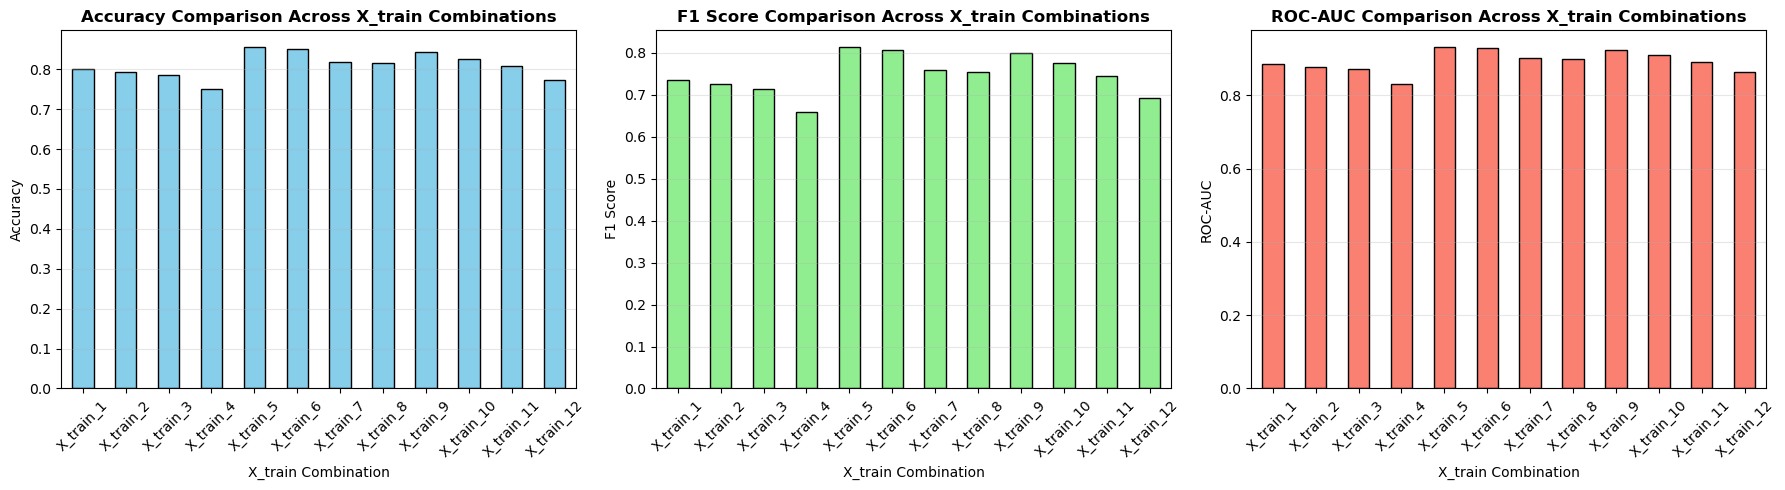


Visualization saved to 'xgboost_model_comparison.png'


In [109]:
# Save results to CSV for later analysis
results_df.to_csv('xgboost_model_comparison_results.csv')
print("\nResults saved to 'xgboost_model_comparison_results.csv'")

# Create visualization of results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy comparison
results_df['accuracy'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Accuracy Comparison Across X_train Combinations', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X_train Combination', fontsize=10)
axes[0].set_ylabel('Accuracy', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# F1 Score comparison
results_df['f1_score'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('F1 Score Comparison Across X_train Combinations', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X_train Combination', fontsize=10)
axes[1].set_ylabel('F1 Score', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# ROC-AUC comparison
results_df['roc_auc'].plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('ROC-AUC Comparison Across X_train Combinations', fontsize=12, fontweight='bold')
axes[2].set_xlabel('X_train Combination', fontsize=10)
axes[2].set_ylabel('ROC-AUC', fontsize=10)
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to 'xgboost_model_comparison.png'")